In [22]:
# anchored_rgb_vs_gray_learning_curve.py
# End-to-end notebook-ready module:
# - Anchors identities by co-occurrence in one frame (auto or given)
# - Stratified random train/val split from the SAME segment (train_split_fraction)
# - RGB vs Gray comparison, with optional sweeps over image scales
# - Canvas tiling: scale image, then center on fixed-size black canvas
# - MPS/CUDA AMP, optional force_half()
# - tqdm progress, debug logs
# - Epoch-wise learning curves + plotting helpers

from __future__ import annotations
from typing import Iterable, Dict, Any, Tuple, List, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt


# -------------------------
# Debug / Utility
# -------------------------
def log(msg: str) -> None:
    print(msg, flush=True)


def _to_float01(x: np.ndarray) -> np.ndarray:
    """Convert image array to float32 in [0,1] regardless of dtype."""
    x = x.astype(np.float32, copy=False)
    if x.size and x.max() > 1.0:
        x /= 255.0
    return x


def _anchor_tracklet_mapping(
    frames: np.ndarray,
    tracklets: np.ndarray,
    anchor_frame: int,
    num_individuals: int,
) -> Dict[int, int]:
    """
    Build a class mapping from the set of tracklets that co-occur in `anchor_frame`.
    Enforces that the count equals `num_individuals`.
    """
    mask_anchor = (frames.astype(np.int64) == int(anchor_frame))
    anchored_tids = np.unique(tracklets[mask_anchor].astype(np.int64))
    if anchored_tids.size == 0:
        raise ValueError(f"No tracklets found at anchor frame {anchor_frame}.")
    if anchored_tids.size != int(num_individuals):
        raise ValueError(
            f"Anchor check failed at frame {anchor_frame}: "
            f"found {anchored_tids.size} tracklets, expected {num_individuals}."
        )
    anchored_tids = np.sort(anchored_tids)
    return {tid: i for i, tid in enumerate(anchored_tids)}


def _stratified_sample_indices(
    indices: np.ndarray, labels: np.ndarray, fraction: float, seed: int = 42
) -> np.ndarray:
    """Return a stratified subset of 'indices' at the given fraction."""
    assert 0 < fraction <= 1.0
    rng = np.random.default_rng(seed)
    per_label: Dict[int, List[int]] = {}
    for idx in indices:
        per_label.setdefault(int(labels[idx]), []).append(int(idx))
    sampled = []
    for _, idxs in per_label.items():
        k = max(1, int(round(len(idxs) * fraction)))
        k = min(k, len(idxs))
        sampled.extend(rng.choice(idxs, size=k, replace=False).tolist())
    rng.shuffle(sampled)
    return np.array(sampled, dtype=np.int64)


def select_device(prefer: Optional[str] = None) -> torch.device:
    """prefer in {'cuda','mps','cpu'} or None for auto: CUDA > MPS > CPU."""
    if prefer:
        d = prefer.lower()
        if d == "cuda" and torch.cuda.is_available():
            return torch.device("cuda")
        if d == "mps" and torch.backends.mps.is_available():
            return torch.device("mps")
        if d == "cpu":
            return torch.device("cpu")
        log(f"[warn] Requested device '{prefer}' not available; falling back to auto.")
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


# -------------------------
# Tiling (scale then paste)
# -------------------------
def _tile_and_scale(
    x_chw: torch.Tensor,            # (C,H,W), float32 [0,1]
    mode: str,                      # "rgb"|"gray"
    canvas_size: Tuple[int, int],   # (Hc, Wc)
    image_scale: float,             # uniform multiplier on original size
    crop_warn_counter: List[int],   # [int] mutable counter for debug prints
    crop_warn_limit: int = 5,
) -> torch.Tensor:
    """
    Convert channels first (RGB<->Gray), resize once, then center-paste on black canvas.
    If scaled image exceeds canvas, center-crop with a limited debug message.
    """
    assert mode in ("rgb", "gray")
    C_in, H, W = x_chw.shape
    Hc, Wc = int(canvas_size[0]), int(canvas_size[1])

    # Convert to desired channel count up front
    if mode == "gray":
        if C_in == 3:
            r, g, b = x_chw[0], x_chw[1], x_chw[2]
            x_chw = (0.2989 * r + 0.5870 * g + 0.1140 * b).unsqueeze(0)  # (1,H,W)
        elif C_in != 1:
            raise ValueError(f"Unexpected channels for gray: {C_in}")
        C_out = 1
    else:  # rgb
        if C_in == 1:
            x_chw = x_chw.repeat(3, 1, 1)
        elif C_in != 3:
            raise ValueError(f"Unexpected channels for rgb: {C_in}")
        C_out = 3

    # Scale
    newH = max(1, int(round(H * image_scale)))
    newW = max(1, int(round(W * image_scale)))
    x_scaled = F.interpolate(x_chw.unsqueeze(0), size=(newH, newW), mode="bilinear", align_corners=False).squeeze(0)

    # Prepare canvas
    canvas = torch.zeros((C_out, Hc, Wc), dtype=x_scaled.dtype)

    # Center paste with clipping if needed
    top = (Hc - newH) // 2
    left = (Wc - newW) // 2

    # Destination window (on canvas)
    dst_y0 = max(0, top)
    dst_x0 = max(0, left)
    dst_y1 = min(Hc, top + newH)
    dst_x1 = min(Wc, left + newW)

    # Source window (on scaled image)
    src_y0 = max(0, -top)
    src_x0 = max(0, -left)
    src_y1 = src_y0 + (dst_y1 - dst_y0)
    src_x1 = src_x0 + (dst_x1 - dst_x0)

    if dst_y1 - dst_y0 <= 0 or dst_x1 - dst_x0 <= 0:
        if crop_warn_counter[0] < crop_warn_limit:
            #log(f"[tile] scaled image ({newH}x{newW}) does not intersect canvas ({Hc}x{Wc}); canvas remains black.")
            crop_warn_counter[0] += 1
        return canvas

    if (newH > Hc) or (newW > Wc):
        if crop_warn_counter[0] < crop_warn_limit:
            #log(f"[tile] cropping scaled image {newH}x{newW} to canvas {Hc}x{Wc} (center-crop).")
            crop_warn_counter[0] += 1

    canvas[:, dst_y0:dst_y1, dst_x0:dst_x1] = x_scaled[:, src_y0:src_y1, src_x0:src_x1]
    return canvas


# -------------------------
# Dataset / Model
# -------------------------
class IdentityDataset(Dataset):
    """
    PyTorch dataset for individual ID classification with tiling.
    - images: float32 (N,H,W,3) in [0,1]
    - labels: int64 (N,)
    - indices: np.ndarray of chosen rows
    - mode: "rgb" or "gray"
    - canvas_size: output HxW
    - image_scale: scale input before tiling
    """
    def __init__(
        self,
        images: np.ndarray,
        labels: np.ndarray,
        indices: np.ndarray,
        mode: str = "rgb",
        canvas_size: Tuple[int, int] = (128, 128),
        image_scale: float = 1.0,
    ):
        assert mode in ("rgb", "gray")
        self.images = images
        self.labels = labels.astype(np.int64, copy=False)
        self.indices = indices.astype(np.int64, copy=False)
        self.mode = mode
        self.canvas_size = (int(canvas_size[0]), int(canvas_size[1]))
        self.image_scale = float(image_scale)
        self._crop_warn_counter = [0]  # mutable for limited debug prints

    def __len__(self) -> int:
        return self.indices.shape[0]

    def __getitem__(self, i: int):
        idx = int(self.indices[i])
        img = self.images[idx]  # H,W,3 float32
        y = int(self.labels[idx])
        t = torch.from_numpy(img).permute(2, 0, 1)  # 3,H,W

        x = _tile_and_scale(
            t, self.mode, self.canvas_size, self.image_scale,
            crop_warn_counter=self._crop_warn_counter
        )
        return x, y


class SmallCNN(nn.Module):
    """Lightweight convnet with configurable input channels; identical across RGB/Gray except in_ch."""
    def __init__(self, in_ch: int, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.head = nn.Linear(128, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = x.flatten(1)
        return self.head(x)


# -------------------------
# Train / Eval with AMP / half
# -------------------------
def train_epochs(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    device: torch.device,
    *,
    class_weights: Optional[torch.Tensor] = None,
    use_amp: bool = True,
    force_half: bool = False,
    epochs: int = 10,
    debug_prefix: str = "",
) -> List[float]:
    """
    Train for `epochs`, return val_acc per epoch (length == epochs).
    Supports CUDA AMP (with GradScaler), MPS autocast(fp16), or forced FP16.
    """
    model.to(device)

    # Precision policy
    if force_half:
        if device.type == "cpu":
            raise ValueError("force_half=True is not supported on CPU.")
        model = model.to(dtype=torch.float16)
        amp_cuda, amp_mps, scaler = False, False, None
        log(f"{debug_prefix}Using FORCE FP16 (model + inputs).")
    else:
        amp_cuda = bool(use_amp and device.type == "cuda")
        amp_mps  = bool(use_amp and device.type == "mps")
        scaler = torch.cuda.amp.GradScaler() if amp_cuda else None
        '''if amp_cuda:
            log(f"{debug_prefix}Using CUDA AMP (autocast + GradScaler).")
        elif amp_mps:
            log(f"{debug_prefix}Using MPS autocast(float16).")
        else:
            log(f"{debug_prefix}Using FP32 (no AMP).")'''

    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device) if class_weights is not None else None)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)

    val_history: List[float] = []
    for ep in range(1, epochs + 1):
        model.train()
        pbar = tqdm(train_loader, desc=f"{debug_prefix}Train ep {ep}/{epochs}", leave=False)
        for xb, yb in pbar:
            if force_half:
                xb = xb.to(device=device, dtype=torch.float16, non_blocking=True)
            else:
                xb = xb.to(device=device, non_blocking=True)
            yb = yb.to(device=device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            if force_half:
                logits = model(xb); loss = criterion(logits, yb)
                loss.backward(); optimizer.step()
            elif amp_cuda:
                with torch.cuda.amp.autocast():
                    logits = model(xb); loss = criterion(logits, yb)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            elif amp_mps:
                with torch.autocast(device_type="mps", dtype=torch.float16):
                    logits = model(xb); loss = criterion(logits, yb)
                loss.backward(); optimizer.step()
            else:
                logits = model(xb); loss = criterion(logits, yb)
                loss.backward(); optimizer.step()

            pbar.set_postfix(loss=float(loss.detach().cpu()))

        # validation
        model.eval()
        correct, total = 0, 0
        pbar_v = tqdm(val_loader, desc=f"{debug_prefix}Val   ep {ep}/{epochs}", leave=False)
        with torch.no_grad():
            for xb, yb in pbar_v:
                if force_half:
                    xb = xb.to(device=device, dtype=torch.float16, non_blocking=True)
                else:
                    xb = xb.to(device=device, non_blocking=True)
                yb = yb.to(device=device, non_blocking=True)

                if force_half:
                    logits = model(xb)
                elif amp_cuda:
                    with torch.cuda.amp.autocast(): logits = model(xb)
                elif amp_mps:
                    with torch.autocast(device_type="mps", dtype=torch.float16): logits = model(xb)
                else:
                    logits = model(xb)

                pred = logits.argmax(dim=1)
                correct += (pred == yb).sum().item()
                total += yb.size(0)
        acc = correct / max(1, total)
        val_history.append(acc)
        #log(f"{debug_prefix}Epoch {ep:02d}: val_acc={acc:.4f}")
    return val_history


# -------------------------
# Preview grid (exact tiling pipeline)
# -------------------------
def preview_grid(
    images_f01: np.ndarray, labels: np.ndarray, indices: np.ndarray,
    mode: str = "rgb",
    canvas_size: Tuple[int, int] = (128, 128),
    image_scale: float = 1.0,
    ncols: int = 6, nrows: int = 4, title: Optional[str] = None, seed: int = 0
):
    rng = np.random.default_rng(seed)
    pick = indices.copy()
    rng.shuffle(pick)
    pick = pick[: min(pick.size, ncols * nrows)]

    fig, axes = plt.subplots(nrows, ncols, figsize=(1.8*ncols, 1.8*nrows))
    axes = axes.ravel()
    crop_warn_counter = [0]

    for ax, idx in zip(axes, pick):
        img = images_f01[idx]  # H,W,3 float32
        t = torch.from_numpy(img).permute(2,0,1)  # 3,H,W
        x = _tile_and_scale(
            t, mode, canvas_size, image_scale, crop_warn_counter=crop_warn_counter
        )
        if mode == "gray":
            ax.imshow(x.squeeze(0).clamp(0,1).cpu().numpy(), cmap="gray", vmin=0, vmax=1)
        else:
            ax.imshow(x.permute(1,2,0).clamp(0,1).cpu().numpy())
        ax.set_title(f"y={int(labels[idx])}", fontsize=9)
        ax.axis("off")

    for j in range(len(pick), len(axes)):
        axes[j].axis("off")

    if title:
        fig.suptitle(title, fontsize=12)
    fig.tight_layout()
    plt.show()


# -------------------------
# Train/Val split + auto-anchor helpers
# -------------------------
def _stratified_train_val_split(
    indices: np.ndarray,
    labels: np.ndarray,
    train_fraction: float,
    seed: int = 42,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Stratified split on 'labels' for 'indices' into train/val according to train_fraction.
    Ensures each class has at least ONE train sample (raises if impossible).
    Val may be empty for rare classes if there is only 1 sample total.
    """
    assert 0.0 < train_fraction < 1.0
    rng = np.random.default_rng(seed)
    per_label: Dict[int, List[int]] = {}
    for idx in indices:
        per_label.setdefault(int(labels[idx]), []).append(int(idx))

    train, val = [], []
    for y, idxs in per_label.items():
        rng.shuffle(idxs)
        n = len(idxs)
        n_train = max(1, int(round(n * train_fraction)))
        # try to leave at least 1 for val when possible
        if n >= 2:
            n_train = min(n_train, n - 1)
        train.extend(idxs[:n_train])
        val.extend(idxs[n_train:])
    rng.shuffle(train); rng.shuffle(val)
    return np.array(train, dtype=np.int64), np.array(val, dtype=np.int64)


def _auto_select_anchor_frame(
    frames: np.ndarray,
    tracklets: np.ndarray,
    num_individuals: int,
) -> int:
    """
    Pick a frame that contains exactly `num_individuals` distinct tracklets.
    Chooses the earliest such frame. Raises with diagnostics if none found.
    """
    frames_u = np.unique(frames.astype(np.int64))
    candidates: List[int] = []
    for f in frames_u:
        k = np.unique(tracklets[frames == f]).size
        if k == int(num_individuals):
            candidates.append(int(f))
    if not candidates:
        counts = [(int(f), np.unique(tracklets[frames == f]).size) for f in frames_u]
        counts.sort(key=lambda t: t[1], reverse=True)
        top = ", ".join([f"{f}:{c}" for f,c in counts[:10]])
        raise ValueError(
            f"No frame has exactly {num_individuals} distinct tracklets. "
            f"Top counts per frame (frame:count) -> {top}"
        )
    return min(candidates)


# -------------------------
# Plotting helper (learning curves from results)
# -------------------------
def plot_learning_curves_from_results(
    results: Dict[str, Any],
    *,
    fraction: Optional[float] = None,
) -> None:
    """
    Plot validation accuracy vs epoch for each configuration in `results["runs"]`.
    If `fraction` is None and multiple fractions exist, plots a separate figure per fraction.
    Lines are labeled as: "{mode} (scale={scale})".
    """
    runs = results.get("runs", [])
    if not runs:
        log("[plot] No runs to plot."); return

    fractions = sorted(set(r["fraction"] for r in runs))
    target_fracs = [fraction] if fraction is not None else fractions

    for f in target_fracs:
        subset = [r for r in runs if abs(r["fraction"] - f) < 1e-12]
        if not subset:
            log(f"[plot] No runs for fraction={f}."); continue

        max_ep = max(len(r["val_acc_per_epoch"]) for r in subset)
        xs = np.arange(1, max_ep + 1)

        plt.figure(figsize=(6, 4))
        for r in subset:
            y = r["val_acc_per_epoch"]
            label = f"{r['mode']} (scale={r['scale']})"
            if r['mode'] == 'rgb':
                color = 'red'
            else:
                color = 'gray'
            
            if len(y) < max_ep:
                y = y + [y[-1]] * (max_ep - len(y))
            plt.plot(xs, y, label=label, marker='o', color=color, alpha=r['scale'])
        plt.xlabel("Epoch")
        plt.ylabel("Validation accuracy")
        plt.ylim(0, 1)
        plt.title(f"Learning curves — fraction={f}")
        plt.legend()
        plt.tight_layout()
        plt.show()


# -------------------------
# Main: anchored comparison
# -------------------------
def compare_rgb_vs_gray_learning_curve_anchored(
    images: np.ndarray,            # (N, H, W, 3) uint8/float
    frames: np.ndarray,            # (N,)
    tracklets: np.ndarray,         # (N,)
    num_individuals: int,          # K
    *,
    train_split_fraction: float = 0.8,          # stratified split within the same segment
    fractions: Tuple[float, ...] = (0.01, 0.05, 0.10, 0.25, 0.50, 1.00),
    canvas_size: Tuple[int, int] = (128, 128),
    image_scale: float = 1.0,                    # used if scales is None
    scales: Optional[Tuple[float, ...]] = None,  # sweep multiple scales; overrides image_scale
    epochs: int = 10,
    batch_size: int = 64,
    num_workers: int = 0,
    seed: int = 42,
    target_acc: Optional[float] = None,          # legacy-style efficiency ratio on first scale
    anchor_frame: Optional[int] = None,          # if None, auto-select a valid frame
    device_preference: Optional[str] = None,
    use_amp: bool = True,
    force_half: bool = False,
    plot_preview: bool = True,
    plot_learning_curves: bool = True,
) -> Dict[str, Any]:
    """
    Anchor classes by co-occurrence in a single frame, then run RGB vs Gray learning curves.
    Train/Val are a stratified random split from the SAME provided segment (no outside frames).

    Returns:
      - results['runs']: list of {mode, scale, fraction, num_train_samples, val_acc_per_epoch, best_val}
      - plus metadata and (optional) data_efficiency_ratio_at_target on the first scale
    """
    # --- setup ---
    torch.manual_seed(seed); np.random.seed(seed)
    device = select_device(device_preference)
    log(f"[setup] Device: {device.type.upper()}  (CUDA avail={torch.cuda.is_available()}, MPS avail={torch.backends.mps.is_available()})")
    if force_half and device.type == "cpu":
        raise ValueError("force_half=True is not supported on CPU.")
    if force_half and use_amp:
        log("[info] force_half=True overrides AMP. Running pure FP16 model+inputs.")

    if images.ndim != 4 or images.shape[-1] != 3:
        raise ValueError("images must have shape (N, H, W, 3)")
    N = images.shape[0]
    if frames.shape[0] != N or tracklets.shape[0] != N:
        raise ValueError("frames and tracklets must have length N")

    images_f = _to_float01(images)
    frames_i = frames.astype(np.int64, copy=False)
    track_i  = tracklets.astype(np.int64, copy=False)

    # --- anchor identities from a single frame ---
    if anchor_frame is None:
        anchor_frame = _auto_select_anchor_frame(frames_i, track_i, num_individuals)
    anchor_frame = int(anchor_frame)
    t2y = _anchor_tracklet_mapping(frames_i, track_i, anchor_frame=anchor_frame, num_individuals=num_individuals)
    anchored_tids = list(t2y.keys())
    log(f"[anchor] frame={anchor_frame}  classes={len(anchored_tids)}  tids={anchored_tids[:8]}{'...' if len(anchored_tids)>8 else ''}")

    # keep only samples from anchored IDs
    keep_mask = np.isin(track_i, anchored_tids)
    images_k = images_f[keep_mask]
    labels_k = np.vectorize(t2y.get, otypes=[np.int64])(track_i[keep_mask]).astype(np.int64)
    idx_all  = np.arange(images_k.shape[0])

    if idx_all.size == 0:
        raise ValueError("No samples remain after anchoring; check inputs.")

    # --- stratified Train/Val split from the SAME segment ---
    train_idx, val_idx = _stratified_train_val_split(idx_all, labels_k, train_fraction=train_split_fraction, seed=seed)
    log(f"[split] train={train_idx.size}  val={val_idx.size}  total_kept={idx_all.size} / N={N}")

    # Ensure each class appears in TRAIN (required to learn)
    train_class_counts = np.bincount(labels_k[train_idx], minlength=num_individuals)
    if (train_class_counts == 0).any():
        missing = np.where(train_class_counts == 0)[0].tolist()
        raise ValueError(
            f"Some classes have no training samples at train_split_fraction={train_split_fraction}: {missing}. "
            f"Increase the fraction or provide more data."
        )
    with np.errstate(divide="ignore"):
        inv_freq = 1.0 / np.maximum(1, train_class_counts)
    class_weights = torch.tensor(inv_freq / inv_freq.mean(), dtype=torch.float32)
    log(f"[classes] per-class train counts: {train_class_counts.tolist()}")
    log(f"[image] canvas_size={canvas_size}")

    # scales to sweep
    scales_to_run = list(scales) if (scales is not None and len(scales) > 0) else [float(image_scale)]
    log(f"[scales] {scales_to_run}")

    # --- run experiments across fractions, scales, modes ---
    runs: List[Dict[str, Any]] = []

    for s in scales_to_run:
        # optional preview (first scale only)
        if plot_preview:
            preview_grid(images_k, labels_k, train_idx, mode="rgb",  canvas_size=canvas_size, image_scale=s,
                        title=f"Training preview (RGB) canvas={canvas_size} scale={s}", seed=seed)
            preview_grid(images_k, labels_k, train_idx, mode="gray", canvas_size=canvas_size, image_scale=s,
                        title=f"Training preview (Gray) canvas={canvas_size} scale={s}", seed=seed)
            
        for frac in fractions:
            # Subsample the TRAIN split only (Approach 2A), stratified by class
            sub_idx = _stratified_sample_indices(train_idx, labels_k, fraction=float(frac), seed=seed)
            n_sub = int(sub_idx.size)
            #log(f"[run] fraction={frac:.2f}  n_train_sub={n_sub}")
                
            # Build loaders for this scale
            val_rgb  = IdentityDataset(images_k, labels_k, val_idx, mode="rgb",
                                       canvas_size=canvas_size, image_scale=s)
            val_gray = IdentityDataset(images_k, labels_k, val_idx, mode="gray",
                                       canvas_size=canvas_size, image_scale=s)
            val_loader_rgb  = DataLoader(val_rgb,  batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
            val_loader_gray = DataLoader(val_gray, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

            # RGB
            train_rgb = IdentityDataset(images_k, labels_k, sub_idx, mode="rgb",
                                        canvas_size=canvas_size, image_scale=s)
            train_loader_rgb = DataLoader(train_rgb, batch_size=batch_size, shuffle=True,
                                          num_workers=num_workers, pin_memory=True, drop_last=False)
            model_rgb = SmallCNN(in_ch=3, num_classes=num_individuals)
            hist_rgb = train_epochs(
                model_rgb, train_loader_rgb, val_loader_rgb, device,
                class_weights=class_weights, use_amp=use_amp, force_half=force_half,
                epochs=epochs, debug_prefix=f"[RGB s={s:.3f} f={frac:.2f}] "
            )
            runs.append({
                "mode": "rgb",
                "scale": float(s),
                "fraction": float(frac),
                "num_train_samples": n_sub,
                "val_acc_per_epoch": [float(a) for a in hist_rgb],
                "best_val": float(max(hist_rgb)) if len(hist_rgb) else 0.0,
            })

            # Gray
            train_gray = IdentityDataset(images_k, labels_k, sub_idx, mode="gray",
                                         canvas_size=canvas_size, image_scale=s)
            train_loader_gray = DataLoader(train_gray, batch_size=batch_size, shuffle=True,
                                           num_workers=num_workers, pin_memory=True, drop_last=False)
            model_gray = SmallCNN(in_ch=1, num_classes=num_individuals)
            hist_gray = train_epochs(
                model_gray, train_loader_gray, val_loader_gray, device,
                class_weights=class_weights, use_amp=use_amp, force_half=force_half,
                epochs=epochs, debug_prefix=f"[GRAY s={s:.3f} f={frac:.2f}] "
            )
            runs.append({
                "mode": "gray",
                "scale": float(s),
                "fraction": float(frac),
                "num_train_samples": n_sub,
                "val_acc_per_epoch": [float(a) for a in hist_gray],
                "best_val": float(max(hist_gray)) if len(hist_gray) else 0.0,
            })

    results = {
        "anchor_frame": int(anchor_frame),
        "train_split_fraction": float(train_split_fraction),
        "fractions": list(fractions),
        "scales": [float(s) for s in scales_to_run],
        "class_mapping": {int(k): int(v) for k, v in t2y.items()},
        "train_class_counts_full": train_class_counts.tolist(),
        "device": device.type,
        "use_amp": bool(use_amp and not force_half),
        "force_half": bool(force_half),
        "canvas_size": tuple(int(x) for x in canvas_size),
        "epochs": int(epochs),
        "batch_size": int(batch_size),
        "runs": runs,
        "data_efficiency_ratio_at_target": None,
    }

    # Optional legacy metric: data-efficiency ratio at first scale
    if target_acc is not None:
        first_scale = results["scales"][0]
        def min_samples_at_target(mode: str) -> Optional[int]:
            cand = [r for r in runs if r["mode"] == mode and abs(r["scale"]-first_scale) < 1e-9]
            best: Dict[float,int] = {}
            for r in cand:
                if any(a >= target_acc for a in r["val_acc_per_epoch"]):
                    best[r["fraction"]] = r["num_train_samples"]
            return min(best.values()) if best else None
        n_rgb, n_gray = min_samples_at_target("rgb"), min_samples_at_target("gray")
        if n_rgb is not None and n_gray is not None:
            results["data_efficiency_ratio_at_target"] = float(n_gray) / float(n_rgb)
            log(f"[summary] Data-efficiency ratio at target {target_acc:.3f} (scale={first_scale}): gray/rgb = {results['data_efficiency_ratio_at_target']:.3f}")

    # Auto-plot epoch-wise learning curves if requested
    if plot_learning_curves:
        plot_learning_curves_from_results(results, fraction=None)

    log("[done] Completed all configurations.")
    return results

In [ ]:
rng = np.random.default_rng(0)
N, K = 1200, 5
# Mix of different native sizes per sample to mimic 64x64, 256x256, etc.
sizes = rng.choice([(64,64), (96,96), (128,128), (192,192), (256,256)], size=N, replace=True)
images = np.zeros((N, max(s[0] for s in sizes), max(s[1] for s in sizes), 3), dtype=np.uint8)  # temp holder

# Create variable-sized crops and pad to the max for storage
true_imgs = []
for (h,w) in sizes:
    arr = rng.integers(0,256,size=(h,w,3), dtype=np.uint8)
    true_imgs.append(arr)
# store as ragged list then stack to common max via per-sample handling: we’ll just keep list here
# For the function we pass a regular array; so instead we choose a fixed (e.g., 256,256) and paste:
images = np.zeros((N, 256, 256, 3), dtype=np.uint8)
for i, arr in enumerate(true_imgs):
    h, w = arr.shape[:2]
    images[i, :h, :w] = arr

frames   = rng.integers(0, 500, size=(N,), dtype=np.int32)
anchor_frame = 100
anchored_tids = np.arange(1000, 1000+K, dtype=np.int64)
tracklets = rng.choice(anchored_tids, size=(N,), replace=True)
# Ensure presence at anchor frame
for j, tid in enumerate(anchored_tids):
    frames[j] = anchor_frame
    tracklets[j] = tid

res = compare_rgb_vs_gray_learning_curve_anchored(
    images, frames, tracklets,
    num_individuals=K,
    train_split_fraction=0.8,
    fractions=(0.10, 0.25, 0.50, 1.00),
    canvas_size=(32,32),     # your "dimensions"
    image_scale=0.5,           # scale first, then center on canvas
    epochs=3,
    batch_size=64,
    num_workers=0,
    seed=42,
    target_acc=0.6,
    device_preference=None,    # auto: CUDA > MPS > CPU
    use_amp=True,
    force_half=False,
    plot_preview=True,
)
res

In [ ]:
import glob 
import numpy as np

images = None
frames = None
tracklets = None

for file in glob.glob("/Users/tristan/Videos/data/hexbug_20251030_14_4k_tracklet_images_single_part*.npz"):
    with np.load(file) as data:
        _images = data["images"]  # (N,H,W,3) uint8
        _frames = data["frames"]  # (N,) int32
        _tracklets = data["frame_segment_indexes"]  # (N, ) int64

        if images is None:
            images = _images
            frames = _frames
            tracklets = _tracklets
        else:
            images = np.concatenate((images, _images), axis=0)
            frames = np.concatenate((frames, _frames), axis=0)
            tracklets = np.concatenate((tracklets, _tracklets), axis=0)

    print(file)

frames[frames == 650]

print(data.files)

print("Loaded images:", images.shape, "frames:", frames.shape, "tracklets:", tracklets.shape)

res = compare_rgb_vs_gray_learning_curve_anchored(
    images, frames, tracklets,
    num_individuals=14,
    train_split_fraction=0.8,
    anchor_frame=650,
    fractions=(0.05, 0.10, 0.25, 0.50, 1.00),
    canvas_size=(32,32),
    scales=( 0.1, 0.2, 0.3, 0.5, 1.0),
    epochs=15,
    batch_size=32,
    num_workers=0,
    seed=123,
    target_acc=0.6,
    device_preference=None,    # auto: CUDA > MPS > CPU
    use_amp=True,
    force_half=False,
    plot_preview=True,
)

In [14]:
res

{'anchor_frame': 650,
 'train_split_fraction': 0.8,
 'fractions': [0.05, 0.1, 0.25, 0.5, 1.0],
 'scales': [0.1, 0.2, 0.3, 0.5, 1.0],
 'class_mapping': {2: 0,
  157: 1,
  286: 2,
  403: 3,
  496: 4,
  603: 5,
  735: 6,
  837: 7,
  969: 8,
  1109: 9,
  1230: 10,
  1358: 11,
  1493: 12,
  1617: 13},
 'train_class_counts_full': [162,
  198,
  501,
  274,
  600,
  343,
  502,
  230,
  456,
  269,
  287,
  119,
  198,
  424],
 'device': 'mps',
 'use_amp': True,
 'force_half': False,
 'canvas_size': (32, 32),
 'epochs': 15,
 'batch_size': 32,
 'runs': [{'mode': 'rgb',
   'scale': 0.1,
   'fraction': 0.05,
   'num_train_samples': 228,
   'val_acc_per_epoch': [0.07530647985989491,
    0.07530647985989491,
    0.07530647985989491,
    0.07530647985989491,
    0.11821366024518389,
    0.07005253940455342,
    0.11471103327495621,
    0.1646234676007005,
    0.3949211908931699,
    0.4448336252189142,
    0.3949211908931699,
    0.5814360770577933,
    0.563922942206655,
    0.5332749562171629,
  

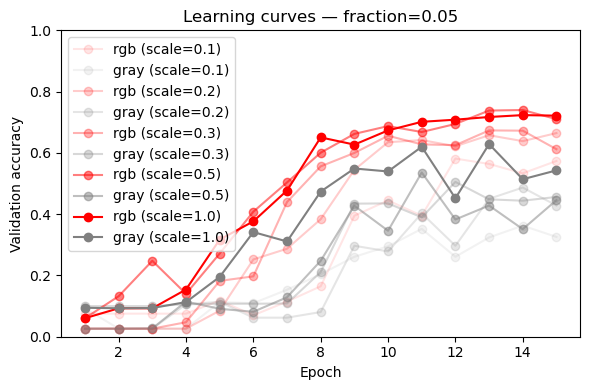

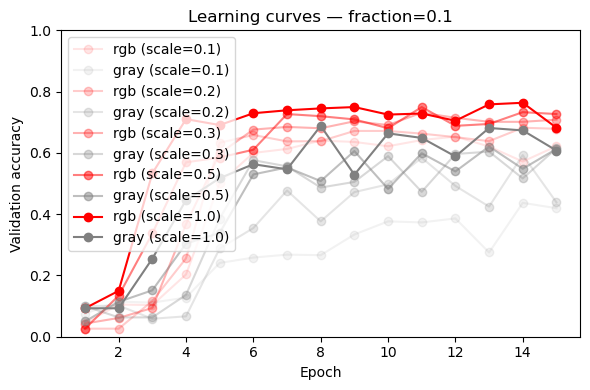

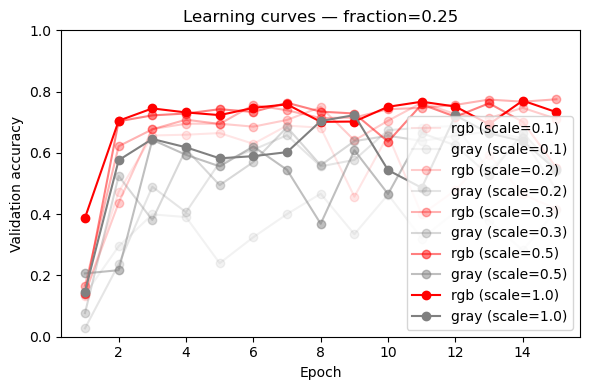

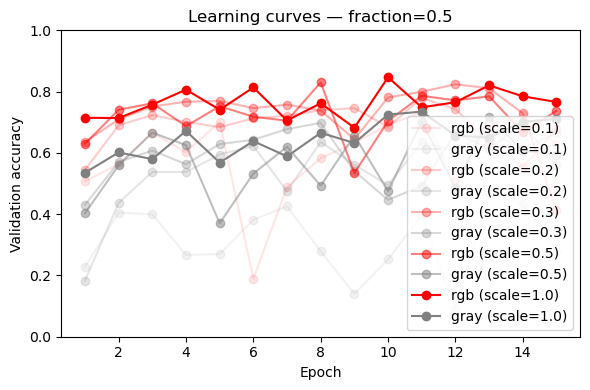

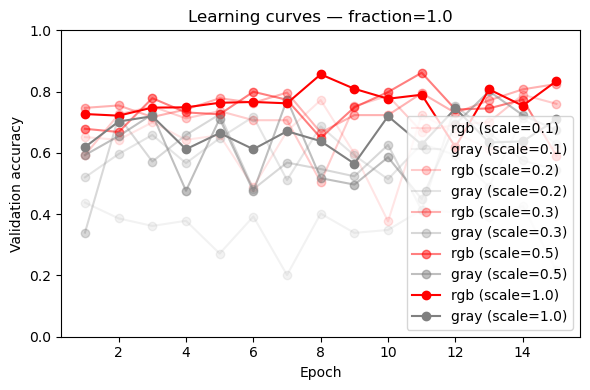

In [23]:
plot_learning_curves_from_results(res, fraction=None)